In [24]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_creation import create_data_all_data, create_data_consolidated_by_store, create_data_consolidated_by_item, create_data_consolidated_by_both
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss

In [26]:
specs = [
    "7_day_rolling_mean",
    "30_day_rolling_mean",
    "90_day_rolling_mean",
    "180_day_rolling_mean",
    "365_day_rolling_mean",
    "7_day_rolling_volatility",
    "30_day_rolling_volatility",
    "90_day_rolling_volatility",
    "180_day_rolling_volatility",
    "365_day_rolling_volatility",
    "7_day_rolling_min",
    "30_day_rolling_min",
    "90_day_rolling_min",
    "180_day_rolling_min",
    "365_day_rolling_min",
    "7_day_rolling_ema",
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "180_day_rolling_ema",
    "365_day_rolling_ema",
    "1_day_lag",
    "2_day_lag",
    "3_day_lag",
    "4_day_lag",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "14_day_lag",
    "28_day_lag",
    "365_day_lag",
    "diff_1_day",
    "diff_7_day",
    "diff_30_day",
    "diff_90_day",
    "diff_180_day",
    "diff_365_day",
]

mod_specs = ["sales", "next_sales"] + specs

In [27]:
# Get data for store 1 item 1
df, drop_columns, target_columns = create_data_all_data(
    specs=specs,
    data_mask=[
        ("store", 1),
        ("item", 1)
    ]
    )
drop_columns.remove("sales")
drop_columns.remove("next_sales")
X = df.drop(columns=drop_columns)
y = df[target_columns]

In [28]:
print(X.columns)

Index(['sales', 'next_sales', '7_day_rolling_mean', '30_day_rolling_mean',
       '90_day_rolling_mean', '180_day_rolling_mean', '365_day_rolling_mean',
       '7_day_rolling_volatility', '30_day_rolling_volatility',
       '90_day_rolling_volatility', '180_day_rolling_volatility',
       '365_day_rolling_volatility', '7_day_rolling_min', '30_day_rolling_min',
       '90_day_rolling_min', '180_day_rolling_min', '365_day_rolling_min',
       '7_day_rolling_ema', '30_day_rolling_ema', '90_day_rolling_ema',
       '180_day_rolling_ema', '365_day_rolling_ema', '1_day_lag', '2_day_lag',
       '3_day_lag', '4_day_lag', '5_day_lag', '6_day_lag', '7_day_lag',
       '14_day_lag', '28_day_lag', '365_day_lag', 'diff_1_day', 'diff_7_day',
       'diff_30_day', 'diff_90_day', 'diff_180_day', 'diff_365_day'],
      dtype='str')


In [29]:
corr_matrix = np.corrcoef(X, rowvar=False)
print(corr_matrix)

[[1.         0.44769507 0.6873393  ... 0.61678596 0.69559629 0.42371468]
 [0.44769507 1.         0.59822572 ... 0.16993626 0.35288098 0.0052307 ]
 [0.6873393  0.59822572 1.         ... 0.28079242 0.48410824 0.07021541]
 ...
 [0.61678596 0.16993626 0.28079242 ... 1.         0.61785282 0.31567394]
 [0.69559629 0.35288098 0.48410824 ... 0.61785282 1.         0.31991776]
 [0.42371468 0.0052307  0.07021541 ... 0.31567394 0.31991776 1.        ]]


/home/normski/miniforge3/envs/trivial/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/normski/miniforge3/envs/trivial/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [30]:
print(corr_matrix.min(), corr_matrix.max())

nan nan


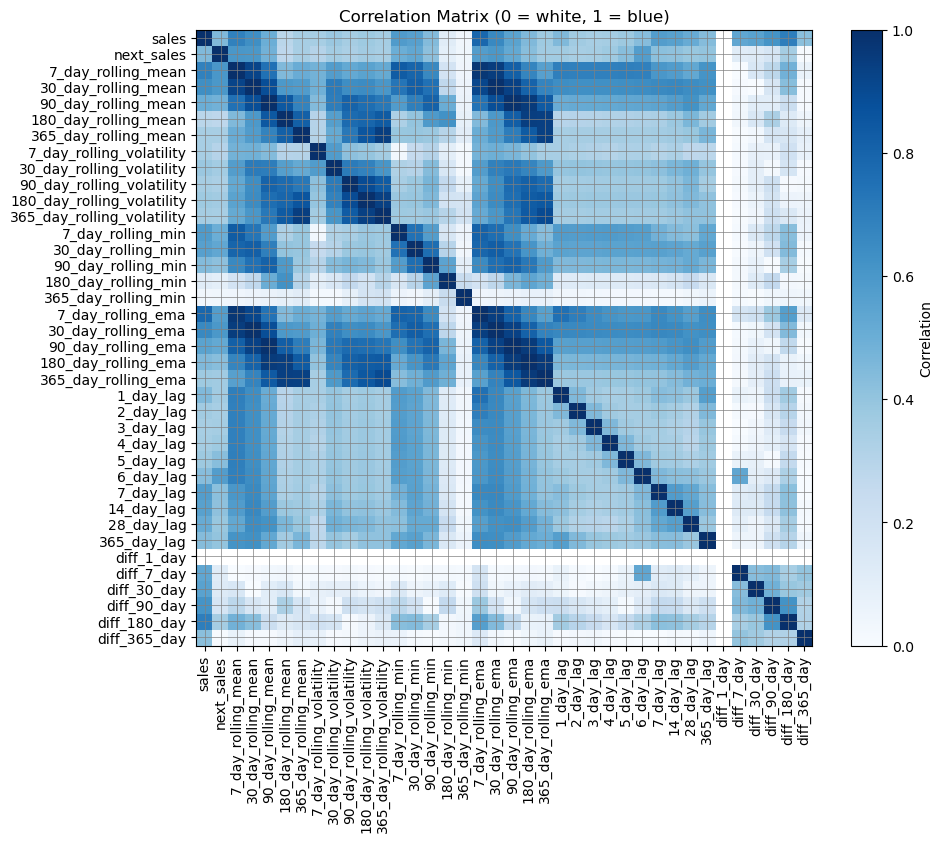

In [31]:
plt.figure(figsize=(10, 8))
plt.imshow(abs(corr_matrix), cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix (0 = white, 1 = blue)')
plt.grid(visible=True, color='gray', linewidth=0.5)
plt.xticks(ticks=np.arange(len(mod_specs)), labels=mod_specs, rotation=90)
plt.yticks(ticks=np.arange(len(mod_specs)), labels=mod_specs)
plt.show()

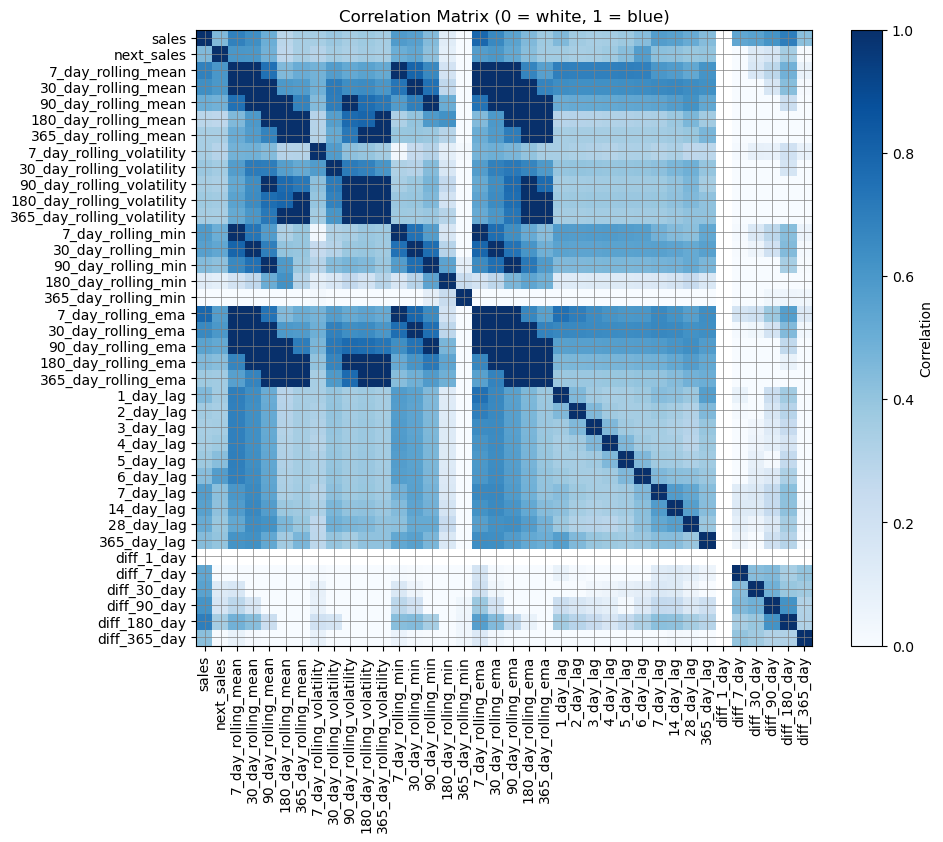

In [34]:
threshold = 0.80
mask = abs(corr_matrix) > threshold
new_corr_matrix = corr_matrix.copy()
new_corr_matrix[mask] = 1
plt.figure(figsize=(10, 8))
plt.imshow(new_corr_matrix, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix (0 = white, 1 = blue)')
plt.grid(visible=True, color='gray', linewidth=0.5)
plt.xticks(ticks=np.arange(len(mod_specs)), labels=mod_specs, rotation=90)
plt.yticks(ticks=np.arange(len(mod_specs)), labels=mod_specs)
plt.show()

In [33]:
# Pearson/Spearman correlations and mutual information (feature x target)
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from IPython.display import display

# Ensure we use numeric arrays and align rows with valid values
Xv = X.values.astype(float)
y_df = y if isinstance(y, pd.DataFrame) else pd.DataFrame(y)
target_names = list(y_df.columns)
feature_names = list(X.columns)
yV = y_df.values.astype(float)
valid = np.isfinite(Xv).all(axis=1) & np.isfinite(yV).all(axis=1)
Xv = Xv[valid]
yV = yV[valid]

n_features = Xv.shape[1]
n_targets = yV.shape[1]

# Pearson correlations
pearson = np.empty((n_features, n_targets), dtype=float)
for t in range(n_targets):
    yt = yV[:, t]
    for i in range(n_features):
        xt = Xv[:, i]
        pearson[i, t] = np.corrcoef(xt, yt)[0, 1] if np.std(xt) > 0 and np.std(yt) > 0 else np.nan

# Spearman correlations: Pearson correlation on ranks (handles non-linearity)
X_rank = pd.DataFrame(Xv).rank(axis=0).to_numpy()
spearman = np.empty((n_features, n_targets), dtype=float)
for t in range(n_targets):
    yr_rank = pd.Series(yV[:, t]).rank().to_numpy()
    for i in range(n_features):
        xr = X_rank[:, i]
        spearman[i, t] = np.corrcoef(xr, yr_rank)[0, 1] if np.std(xr) > 0 and np.std(yr_rank) > 0 else np.nan

# Mutual information (regression): MI(feature, target) >= 0
mi = np.empty((n_features, n_targets), dtype=float)
for t in range(n_targets):
    mi[:, t] = mutual_info_regression(Xv, yV[:, t], random_state=0)

pearson_df = pd.DataFrame(pearson, index=feature_names, columns=target_names)
spearman_df = pd.DataFrame(spearman, index=feature_names, columns=target_names)
mi_df = pd.DataFrame(mi, index=feature_names, columns=target_names)

# Order Pearson and Spearman and MI by abs of value
pearson_df = pearson_df.abs().sort_values(by=target_names[0], ascending=False)
spearman_df = spearman_df.abs().sort_values(by=target_names[0], ascending=False)
mi_df = mi_df.abs().sort_values(by=target_names[0], ascending=False)

print('Pearson correlation (feature x target):')
display(pearson_df)
print('Spearman correlation (feature x target):')
display(spearman_df)
print('Mutual information (feature x target) - regression:')
display(mi_df)

# Convenience: top MI feature per target
top_mi = mi_df.idxmax(axis=0)
print('Top MI feature per target:')
display(top_mi)

Pearson correlation (feature x target):


,next_sales
next_sales,1.000000
7_day_rolling_mean,0.598226
30_day_rolling_mean,0.596215
30_day_rolling_ema,0.594867
6_day_lag,0.572520
7_day_rolling_ema,0.571286
30_day_rolling_min,0.530039
90_day_rolling_ema,0.520797
7_day_rolling_min,0.497215
90_day_rolling_mean,0.482339


Spearman correlation (feature x target):


,next_sales
next_sales,1.000000
7_day_rolling_mean,0.607654
30_day_rolling_ema,0.598263
30_day_rolling_mean,0.597945
7_day_rolling_ema,0.582112
6_day_lag,0.571640
30_day_rolling_min,0.538171
90_day_rolling_ema,0.520637
7_day_rolling_min,0.507833
90_day_rolling_mean,0.480231


Mutual information (feature x target) - regression:


,next_sales
next_sales,3.301288
30_day_rolling_ema,0.255984
7_day_rolling_ema,0.215348
30_day_rolling_mean,0.212437
7_day_rolling_mean,0.201264
6_day_lag,0.188403
365_day_rolling_mean,0.179457
30_day_rolling_min,0.178718
7_day_rolling_min,0.162471
90_day_rolling_mean,0.152997


Top MI feature per target:


next_sales    next_sales
dtype: str